In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.fftpack import dct

In [2]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Load audio
signal, sr = librosa.load(file_name, sr=None)

print("Sampling Rate:", sr)
print("Signal Length:", len(signal))

Saving LJ037-0171.wav to LJ037-0171.wav
Sampling Rate: 22050
Signal Length: 167226


In [3]:
frame_size = int(0.025 * sr)  # 25 ms
frame = signal[:frame_size]

# Apply Hamming window
hamming_window = np.hamming(frame_size)
windowed_frame = frame * hamming_window

In [4]:
# DFT
dft = np.fft.fft(windowed_frame)
dft_magnitude = np.abs(dft)

# DCT
dct_coeff = dct(windowed_frame, norm='ortho')

In [5]:
def energy_compaction(coeffs, k):
    total_energy = np.sum(coeffs**2)
    partial_energy = np.sum(coeffs[:k]**2)
    return partial_energy / total_energy

k_values = [5, 10, 20, 50]

print("Energy Compaction Comparison:\n")

for k in k_values:
    dft_energy = energy_compaction(dft_magnitude, k)
    dct_energy = energy_compaction(dct_coeff, k)
    print(f"Top {k} Coefficients → DFT: {dft_energy:.4f}, DCT: {dct_energy:.4f}")

Energy Compaction Comparison:

Top 5 Coefficients → DFT: 0.0010, DCT: 0.0001
Top 10 Coefficients → DFT: 0.0130, DCT: 0.0018
Top 20 Coefficients → DFT: 0.1410, DCT: 0.0271
Top 50 Coefficients → DFT: 0.1842, DCT: 0.2967


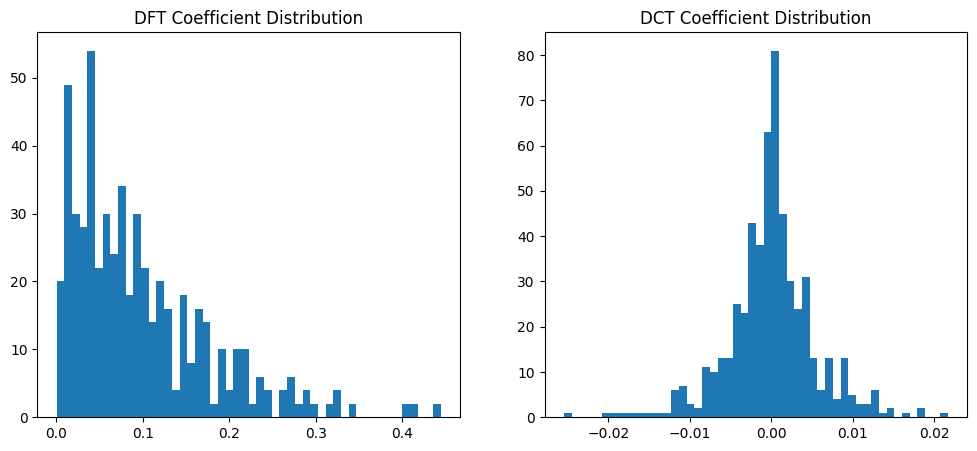

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(dft_magnitude, bins=50)
plt.title("DFT Coefficient Distribution")

plt.subplot(1,2,2)
plt.hist(dct_coeff, bins=50)
plt.title("DCT Coefficient Distribution")

plt.show()

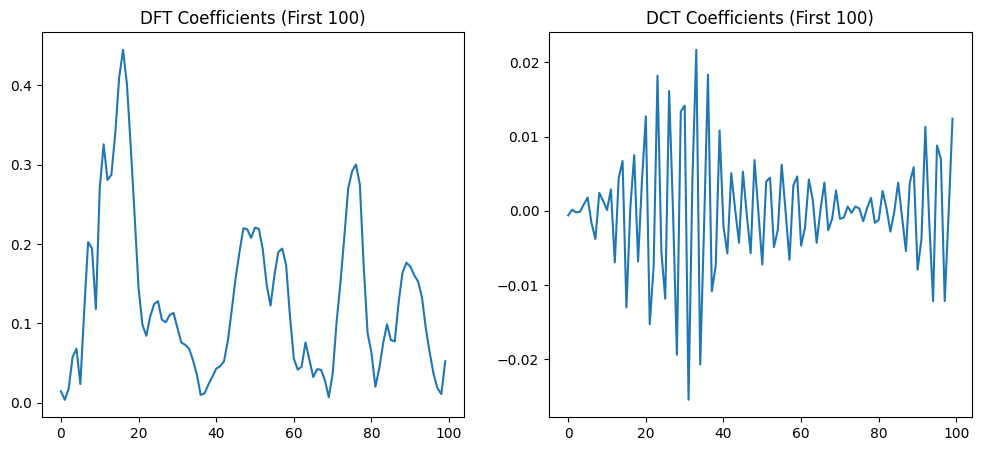

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(dft_magnitude[:100])
plt.title("DFT Coefficients (First 100)")

plt.subplot(1,2,2)
plt.plot(dct_coeff[:100])
plt.title("DCT Coefficients (First 100)")

plt.show()

In [8]:
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

print("MFCC Shape:", mfccs.shape)

MFCC Shape: (13, 327)


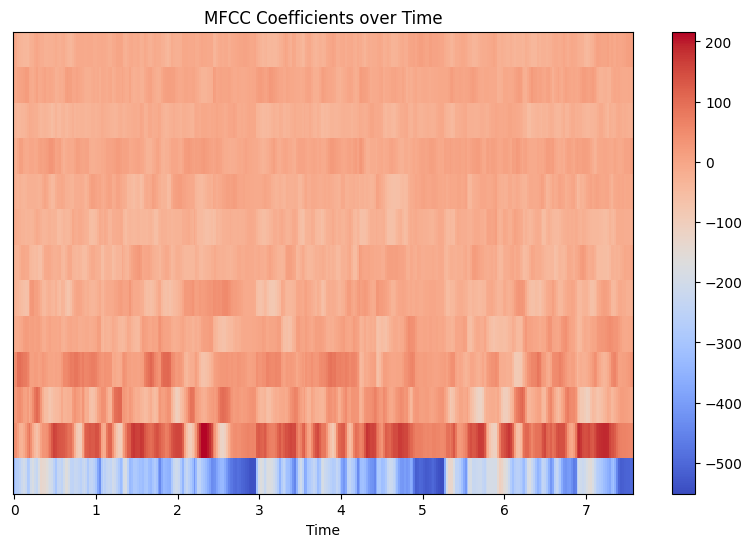

In [9]:
plt.figure(figsize=(10,6))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC Coefficients over Time")
plt.show()

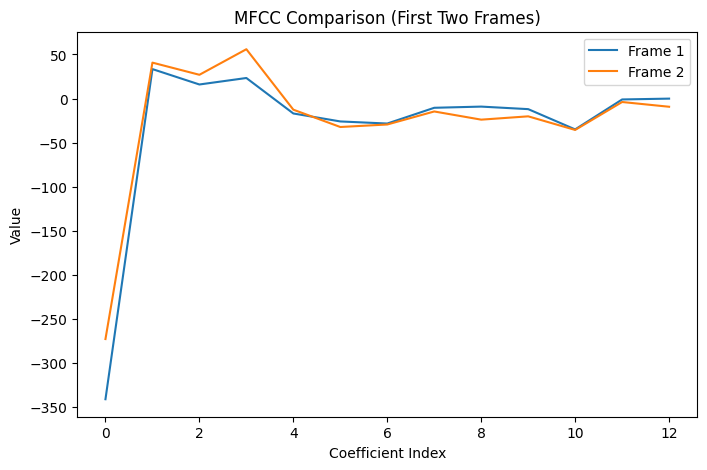

In [10]:
plt.figure(figsize=(8,5))

plt.plot(mfccs[:,0], label="Frame 1")
plt.plot(mfccs[:,1], label="Frame 2")

plt.title("MFCC Comparison (First Two Frames)")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.legend()

plt.show()